# mlops
## the questions that are needed to ask for the deployment
* what is my most ideal ml model deployment scenarion(works everytime with speed of light)
* where is my model goint to go?(on device and cloud)
* how is my model going to fuction?(online real time and offline batch)

In [1]:
# the dataset we are gonna use for the forr vision mini model is pizza steak shushi 20%
import torch
import torchvision
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
from pathlib import Path
data_20_percent_path=Path("data/pizza_steak_sushi_20_percent")
data_20_percent_path

WindowsPath('data/pizza_steak_sushi_20_percent')

In [3]:
#setup training and test paths
train_dir=data_20_percent_path/"train"
test_dir=data_20_percent_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

we are going to train two model effecientnetb2 and vit feature extractor and compare their accuracy and latency before deployment

In [4]:
#creating effnetb2 feature extractor
import torchvision
#pretrained weight(transfer the learnings)
effnetb2_weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

#get effnetb2 transofrmer
effnetb2_transforms=effnetb2_weights.transforms()

#setup pretrained model instance
effnetb2=torchvision.models.efficientnet_b2(weights=effnetb2_weights)

#freeze the base layer in the model(this wil stop all layers from training)
for param in effnetb2.parameters():
    param.requires_grad=False

In [5]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   False
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16,

In [6]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [7]:
#set
from helper_functions import set_seeds
from torch import nn
set_seeds()
effnetb2.classifier=nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408,out_features=3,bias=True)
)

In [8]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [9]:
#creating the fuction for making the effnetb2 feature extractor
import torchvision
import torch
from torch import nn
def create_effnetb2_model(num_classes:int=3,
                          seed:int=42):
   
    #pretrained weight(transfer the learnings)
    weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

    #get effnetb2 transofrmer
    transforms=weights.transforms()

    #setup pretrained model instance
    model=torchvision.models.efficientnet_b2(weights=weights)

    #freeze the base layer in the model(this wil stop all layers from training)
    for param in model.parameters():
        param.requires_grad=False

    #change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier=nn.Sequential(
        nn.Dropout(p=0.3,inplace=True),
        nn.Linear(in_features=1408,out_features=num_classes)
    )
    return model,transforms

In [10]:
effnetb2,effnetb2_transforms=create_effnetb2_model(num_classes=3,seed=42)

In [11]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [12]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [13]:
#creating dataloaders for effnetb2
from going_modular import data_setup
train_dataloader_effnetb2,test_dataloader_effnetb2,class_names=data_setup.create_dataloaders(train_dir=train_dir,
                                                                                             test_dir=test_dir,
                                                                                             transform=effnetb2_transforms,
                                                                                             batch_size=32)

In [14]:
len(train_dataloader_effnetb2),len(test_dataloader_effnetb2),class_names

(15, 5, ['pizza', 'steak', 'sushi'])

In [ ]:
#training the effnetb2 feature extractor
from going_modular import engine
#loss fun
loss_fn=torch.nn.CrossEntropyLoss()

#optimizer
optimizer=torch.optim.Adam(params=effnetb2.parameters(),
                           lr=1e-3)

#training function 
set_seeds()
effnetb2_results=engine.train(model=effnetb2,
                              train_dataloader=train_dataloader_effnetb2,
                              test_dataloader=test_dataloader_effnetb2,
                              epochs=10,#no of epochs taken from the 8_experiment_tracking
                              optimizer=optimizer,
                              loss_fn=loss_fn,
                              device=device)


C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 10%|█         | 1/10 [00:06<01:00,  6.74s/it]

Epoch: 1 | train_loss: 0.9832 | train_acc: 0.5750 | test_loss: 0.7411 | test_acc: 0.9409


 20%|██        | 2/10 [00:12<00:49,  6.20s/it]

Epoch: 2 | train_loss: 0.7182 | train_acc: 0.8479 | test_loss: 0.5867 | test_acc: 0.9347


 30%|███       | 3/10 [00:18<00:42,  6.05s/it]

Epoch: 3 | train_loss: 0.5841 | train_acc: 0.8958 | test_loss: 0.4876 | test_acc: 0.9625


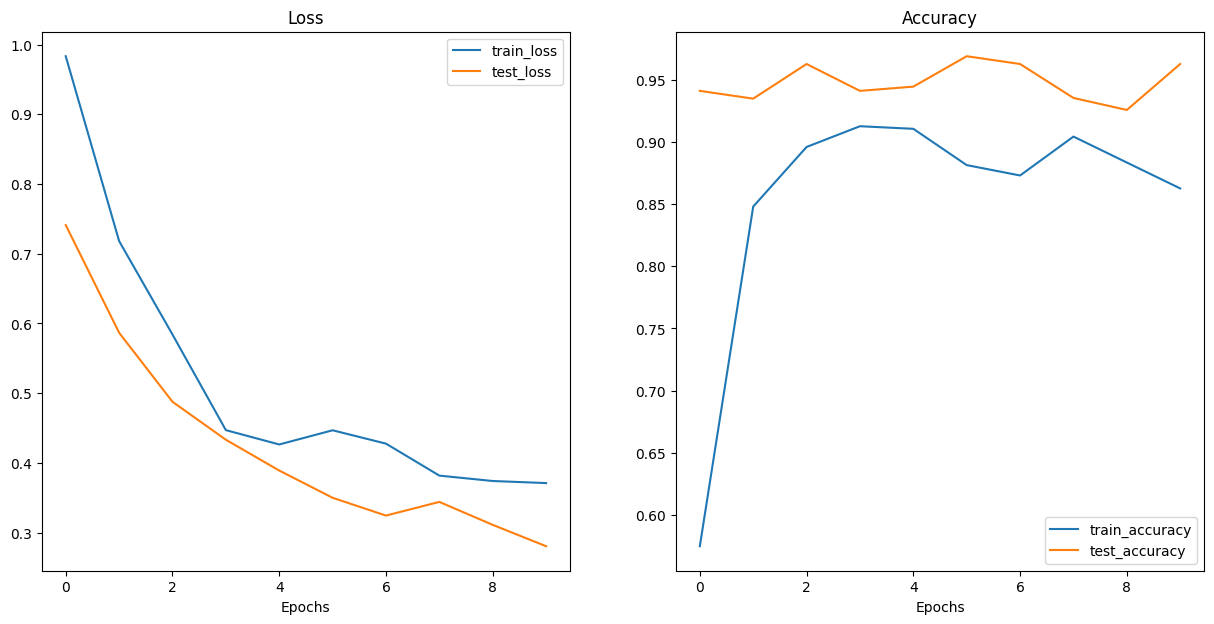

In [ ]:
#visulainzing the loss curve
from going_modular.helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [ ]:
# saving effnetb2 feature extractor
from going_modular import utils

utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth")


[INFO] Saving model to: models\10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth


In [ ]:
#size of the model
from pathlib import Path

pretrained_effnetb2_model_size=Path("models/10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth").stat().st_size/(1024*1024)
print(f"The size of the pretrained effnet model is :{round(pretrained_effnetb2_model_size,2)} MB")

The size of the pretrained effnet model is :29.86 MB


In [ ]:
#count number of parameters in effnetb2
effnetb2_total_params=sum(torch.numel(param) for param in effnetb2.parameters())

effnetb2_total_params

7705221

In [ ]:
#creating a dictionary with effnetb2 statistics
effnetb2_stat={"test_loss":effnetb2_results["test_loss"][-1],
               "test_acc":effnetb2_results["test_acc"][-1],
               "number_of_parameters":effnetb2_total_params,
               "model_size(MB)":pretrained_effnetb2_model_size}
effnetb2_stat

{'test_loss': 0.2804704368114471,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.864014625549316}